In [ ]:
!pip install equinox

In [ ]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax

import numpy as np
import matplotlib.pyplot as plt

import glob
import os
import pandas as pd
import pickle
import random
import copy
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define folder path
folder_path = '/content/drive/MyDrive/coding/romero_shots_489'
pickle_output = 'combined_data.pkl'

# Find all CSV files in the folder
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

In [ ]:
dfb = pd.read_csv(all_files[0], nrows=0)
header_list = dfb.columns.tolist()

print(len(all_files))
print(all_files[:3])

489
['/content/drive/MyDrive/coding/romero_shots_489/romero2_shot_1050303014.csv', '/content/drive/MyDrive/coding/romero_shots_489/romero2_shot_1150826025.csv', '/content/drive/MyDrive/coding/romero_shots_489/romero2_shot_1150505033.csv']


In [ ]:
df_list = []

for filename in all_files:
    df = pd.read_csv(filename)
    df_list.append(df)

print(df_list[0].columns)

Index(['shot', 'time', 'dip_dt', 'li', 'kappa', 'dli_dt', 'ip', 'ip_MA', 'Li',
       'vc_minus_vb', 'Vind'],
      dtype='object')


In [ ]:
def moving_average(x, window=3):
    kernel = jnp.ones(window) / window
    return jnp.convolve(x, kernel, mode="same")


def backward_slopes(y, time):
    dy = y[1:] - y[:-1]
    dt = time[1:] - time[:-1]

    slopes = jnp.zeros_like(y)
    slopes = slopes.at[1:].set(dy / (dt + 1e-8))
    slopes = slopes.at[0].set(slopes[1])
    return slopes


group_size = 10
stride = 10

def check_batch_finite(batch, name):
    init_states, controls, targets = batch

    for tree_name, tree in [
        ("init_states", init_states),
        ("controls", controls),
        ("targets", targets),
    ]:
        for k, v in tree.items():
            print(name, tree_name, k, jnp.all(jnp.isfinite(v)), v.shape)

In [ ]:
def build_episodes(df_subset, group_size=10, stride=10):

    episodes = []

    for df in df_subset:

        time = jnp.array(df["time"].values)
        li = jnp.array(df["li"].values)
        ip = jnp.array(df["ip_MA"].values)
        V  = jnp.array(df["vc_minus_vb"].values)
        Vind = jnp.array(df["Vind"].values)

        Vind_slope = backward_slopes(Vind, time)

        T = len(li)

        for start in range(0, T - group_size, stride):

            init_state = {
                "li": li[start],
                "ip_MA": ip[start],
                "vc_minus_vb": V[start],
            }

            controls = {
                "time": time[start:start + group_size],
                "Vind": Vind[start:start + group_size],
                "Vind_slope": Vind_slope[start:start + group_size],
            }

            targets = {
                "li": li[start:start + group_size],
                "ip_MA": ip[start:start + group_size],
                "vc_minus_vb": V[start:start + group_size],
            }

            episodes.append((init_state, controls, targets))

    return episodes

In [ ]:
def stack_episodes(eps):
    init_states = {
        k: jnp.stack([ep[0][k] for ep in eps])
        for k in eps[0][0].keys()
    }

    controls = {
        k: jnp.stack([ep[1][k] for ep in eps])
        for k in eps[0][1].keys()
    }

    targets = {
        k: jnp.stack([ep[2][k] for ep in eps])
        for k in eps[0][2].keys()
    }

    return init_states, controls, targets

In [ ]:
random.shuffle(df_list)

n_shots = len(df_list)

train_end = int(0.7 * n_shots)
val_end   = int(0.85 * n_shots)

train_dfs = df_list[:train_end]
val_dfs   = df_list[train_end:val_end]
test_dfs  = df_list[val_end:]

train_eps = build_episodes(train_dfs, group_size, stride)
val_eps   = build_episodes(val_dfs, group_size, stride)
test_eps  = build_episodes(test_dfs, group_size, stride)

print("Train shots:", len(train_dfs))
print("Val shots:", len(val_dfs))
print("Test shots:", len(test_dfs))

print("Train episodes:", len(train_eps))
print("Val episodes:", len(val_eps))
print("Test episodes:", len(test_eps))

train_batch = stack_episodes(train_eps)
val_batch   = stack_episodes(val_eps)
test_batch  = stack_episodes(test_eps)

check_batch_finite(train_batch, "train")
check_batch_finite(val_batch, "val")
check_batch_finite(test_batch, "test")

Train shots: 342
Val shots: 73
Test shots: 74
Train episodes: 754
Val episodes: 161
Test episodes: 164
train init_states li True (754,)
train init_states ip_MA True (754,)
train init_states vc_minus_vb True (754,)
train controls time True (754, 10)
train controls Vind True (754, 10)
train controls Vind_slope True (754, 10)
train targets li True (754, 10)
train targets ip_MA True (754, 10)
train targets vc_minus_vb True (754, 10)
val init_states li True (161,)
val init_states ip_MA True (161,)
val init_states vc_minus_vb True (161,)
val controls time True (161, 10)
val controls Vind True (161, 10)
val controls Vind_slope True (161, 10)
val targets li True (161, 10)
val targets ip_MA True (161, 10)
val targets vc_minus_vb True (161, 10)
test init_states li True (164,)
test init_states ip_MA True (164,)
test init_states vc_minus_vb True (164,)
test controls time True (164, 10)
test controls Vind True (164, 10)
test controls Vind_slope True (164, 10)
test targets li True (164, 10)
test tar

In [ ]:
class RomeroNNV(eqx.Module):
    mlp: eqx.nn.MLP
    romero_norm: float

    alpha_ip: jnp.ndarray
    alpha_li: jnp.ndarray

    def __init__(self, key):
        self.mlp = eqx.nn.MLP(
            in_size=4,
            out_size=1,
            width_size=32,
            depth=2,
            key=key,
            activation=jax.nn.softplus,
        )
        self.romero_norm = 3.6559
        # trainable parameters, ie constants/normalizations I can't figure out
        self.alpha_ip = jnp.array(1.0)
        self.alpha_li = jnp.array(1.0)

    def __call__(self, state, control):
        li = state["li"]
        ip = state["ip_MA"]
        V = state["vc_minus_vb"]
        Vind = control["Vind"]

        Vb_minus_Vr = Vind
        Vr_minus_Vb = -Vb_minus_Vr

        li_dot = self.alpha_li * (2 * Vr_minus_Vb - 2 * V) / (self.romero_norm * ip)
        ip_dot = self.alpha_ip * (2 * Vb_minus_Vr + V) / (self.romero_norm * li)

        inputs = jnp.array([li, ip, V, Vind])
        V_dot = self.mlp(inputs)[0]

        return {
            "li": li_dot,
            "ip_MA": ip_dot,
            "vc_minus_vb": V_dot,
        }

In [ ]:
def step(model, state, control, dt):
    state_dot = model(state, control)
    return jax.tree_util.tree_map(
        lambda s, ds: s + dt * ds,
        state,
        state_dot,
    )

In [ ]:
def rollout(model, init_state, controls, dt):
    def body_fn(state, control_t):
        control = {"Vind": control_t}
        next_state = step(model, state, control, dt)
        return next_state, next_state

    _, states = jax.lax.scan(body_fn, init_state, controls["Vind"])
    return states

In [ ]:
def mse_pytree(pred, target):
    leaves_pred = jax.tree_util.tree_leaves(pred)
    leaves_target = jax.tree_util.tree_leaves(target)
    return sum(jnp.mean((p - t) ** 2) for p, t in zip(leaves_pred, leaves_target))

In [ ]:
def loss_fn(model):
    preds = model(init_state, controls)

    pred_leaves = jax.tree_util.tree_leaves(preds)
    target_leaves = jax.tree_util.tree_leaves(targets)

    dt = 0.01  #initially set to 1 but changed back original delta_t

    losses = []

    for p, t in zip(pred_leaves, target_leaves):
        rel_error = (p - t) / (jnp.abs(t) + 1e-6)

        # Huber loss (delta = 0.1)
        delta = 0.1
        abs_err = jnp.abs(rel_error)

        huber = jnp.where(
            abs_err < delta,
            0.5 * rel_error**2,
            delta * (abs_err - 0.5 * delta)
        )

         # trapezoidal integration
        integrated = jnp.sum(
          0.5 * (huber[:-1] + huber[1:])
        )

        losses.append(jnp.mean(huber))

    return sum(losses)

In [ ]:
def single_trajectory_loss(model, init_state, controls, targets):
    preds = model(init_state, controls)
    return trajectory_loss(preds, targets, controls)

In [ ]:
#Added Learning Rate Scheduler
def make_lr_schedule():
    base_lr = 5e-3
    decay_rate = 0.995
    min_lr = 1e-4

    schedule = optax.exponential_decay(
        init_value=base_lr,
        transition_steps=1,   # per epoch
        decay_rate=decay_rate,
        staircase=False,
    )

    def lr_fn(step):
        return jnp.maximum(schedule(step), min_lr)

    return lr_fn

In [ ]:
def evaluate_with_model(model, episodes):
    total = 0.0

    for init_state, controls, targets in episodes:
        preds = model(init_state, controls)
        loss = trajectory_loss(preds, targets, controls)
        total += loss

    return float(total)


def evaluate(episodes):
    return evaluate_with_model(model, episodes)

In [ ]:
def trajectory_loss(preds, targets, controls):
    losses = []

    time = controls["time"]
    dt = time[1:] - time[:-1]

    # -------------------
    # Main Wang-style loss: li and ip only
    # -------------------
    for key in ["li", "ip_MA"]:
        p = preds[key]
        t = targets[key]

        rel_error = jnp.abs(t - p) / (jnp.abs(t) + 1e-6)
        huber = optax.huber_loss(rel_error, delta=0.1)

        integrated = jnp.sum(
            0.5 * (huber[:-1] + huber[1:]) * dt
        )

        losses.append(integrated)

    return sum(losses)

In [ ]:
@eqx.filter_jit
def train_step_batched(model, opt_state, batch, optimizer):

    init_states, controls, targets = batch

    def loss_fn(model):
        losses = jax.vmap(
            lambda s, c, t: single_trajectory_loss(model, s, c, t),
            in_axes=(0, 0, 0)
        )(init_states, controls, targets)

        return jnp.mean(losses)

    loss, grads = eqx.filter_value_and_grad(loss_fn)(model)

    updates, opt_state = optimizer.update(
        grads,
        opt_state,
        model
    )

    model = eqx.apply_updates(model, updates)

    return model, opt_state, loss

In [ ]:
@eqx.filter_jit
def evaluate_batch_jit(model, batch):
    init_states, controls, targets = batch

    losses = jax.vmap(
        lambda s, c, t: single_trajectory_loss(model, s, c, t),
        in_axes=(0, 0, 0)
    )(init_states, controls, targets)

    return jnp.mean(losses)

In [ ]:
def hermite_interp(y0, y1, m0, m1, h, s):
    h00 = 2*s**3 - 3*s**2 + 1
    h10 = s**3 - 2*s**2 + s
    h01 = -2*s**3 + 3*s**2
    h11 = s**3 - s**2

    return h00*y0 + h10*h*m0 + h01*y1 + h11*h*m1


class SimFullObs(eqx.Module):
    dynamics: eqx.Module

    def interp_control(self, controls, i, s):
        time = controls["time"]
        Vind = controls["Vind"]
        slope = controls["Vind_slope"]

        t0 = time[i]
        t1 = time[i + 1]
        h = t1 - t0

        Vind_s = hermite_interp(
            Vind[i],
            Vind[i + 1],
            slope[i],
            slope[i + 1],
            h,
            s,
        )

        return {"Vind": Vind_s}

    def rk4_interval(self, state, controls, i, n_substeps=2):
      h_total = controls["time"][i + 1] - controls["time"][i]
      h = h_total / n_substeps

      def substep_fn(state, j):
          s0 = j / n_substeps
          s1 = (j + 1) / n_substeps
          sm = 0.5 * (s0 + s1)

          # Same RK4, but over sub-interval [s0, s1]
          u1 = self.interp_control(controls, i, s0)
          k1 = self.dynamics(state, u1)

          state2 = jax.tree_util.tree_map(lambda x, k: x + 0.5 * h * k, state, k1)
          u2 = self.interp_control(controls, i, sm)
          k2 = self.dynamics(state2, u2)

          state3 = jax.tree_util.tree_map(lambda x, k: x + 0.5 * h * k, state, k2)
          u3 = self.interp_control(controls, i, sm)
          k3 = self.dynamics(state3, u3)

          state4 = jax.tree_util.tree_map(lambda x, k: x + h * k, state, k3)
          u4 = self.interp_control(controls, i, s1)
          k4 = self.dynamics(state4, u4)

          next_state = jax.tree_util.tree_map(
              lambda x, k1, k2, k3, k4: x + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4),
              state, k1, k2, k3, k4
          )
          return next_state, None

      state, _ = jax.lax.scan(substep_fn, state, jnp.arange(n_substeps))
      return state

    def __call__(self, init_state, controls):
        # T samples means T-1 integration intervals
        T = controls["Vind"].shape[0]

        def step_fn(state, i):
            #next_state = self.rk4_step(state, controls, i)
            next_state = self.rk4_interval(state, controls, i, n_substeps=2)
            return next_state, next_state

        _, trajectory = jax.lax.scan(
            step_fn,
            init_state,
            jnp.arange(T - 1),
        )

        # prepend initial state so prediction length matches targets length T
        trajectory = jax.tree_util.tree_map(
            lambda x0, xs: jnp.concatenate([x0[None], xs], axis=0),
            init_state,
            trajectory,
        )

        return trajectory

In [ ]:
key = jax.random.PRNGKey(0)

# Split immediately for different purposes
key, model_key, data_key = jax.random.split(key, 3)

In [ ]:
model = SimFullObs(
    RomeroNNV(model_key)
)

In [ ]:
lr_schedule = make_lr_schedule()

optimizer = optax.chain(
    optax.zero_nans(),
    optax.clip_by_global_norm(1.0),
    optax.adamw(
        learning_rate=lr_schedule,
        weight_decay=1e-4
    )
)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

val_history = []
train_history = []

best_val = float("inf")
best_model = copy.deepcopy(model)

num_epochs = 3000

for epoch in range(num_epochs):

    model, opt_state, train_loss = train_step_batched(
        model,
        opt_state,
        train_batch,
        optimizer
    )

    val_loss = float(evaluate_batch_jit(model, val_batch))

    train_history.append(float(train_loss))
    val_history.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        best_model = copy.deepcopy(model)

    if epoch % 250 == 0:
        print(
            f"Epoch {epoch}, "
            f"Train Loss: {float(train_loss):.6f}, "
            f"Val Loss: {val_loss:.6f}"
        )

Epoch 0, Train Loss: 0.000510, Val Loss: 0.000481
Epoch 250, Train Loss: 0.000141, Val Loss: 0.000130
Epoch 500, Train Loss: 0.000130, Val Loss: 0.000122
Epoch 750, Train Loss: 0.000129, Val Loss: 0.000120
Epoch 1000, Train Loss: 0.000128, Val Loss: 0.000119
Epoch 1250, Train Loss: 0.000127, Val Loss: 0.000119
Epoch 1500, Train Loss: 0.000126, Val Loss: 0.000118
Epoch 1750, Train Loss: 0.000126, Val Loss: 0.000117
Epoch 2000, Train Loss: 0.000125, Val Loss: 0.000117
Epoch 2250, Train Loss: 0.000124, Val Loss: 0.000116
Epoch 2500, Train Loss: 0.000124, Val Loss: 0.000116
Epoch 2750, Train Loss: 0.000123, Val Loss: 0.000115


In [ ]:
best_test_loss = float(evaluate_batch_jit(best_model, test_batch))
print(f"Final Best Test Loss: {best_test_loss:.6f}")

Final Best Test Loss: 0.000117


In [ ]:
init_state, controls, targets = test_eps[0]
preds = best_model(init_state, controls)

In [ ]:
targets_np = np.stack([targets["li"], targets["ip_MA"], targets["vc_minus_vb"]], axis=-1)
preds_np = np.stack([preds["li"], preds["ip_MA"], preds["vc_minus_vb"]], axis=-1)

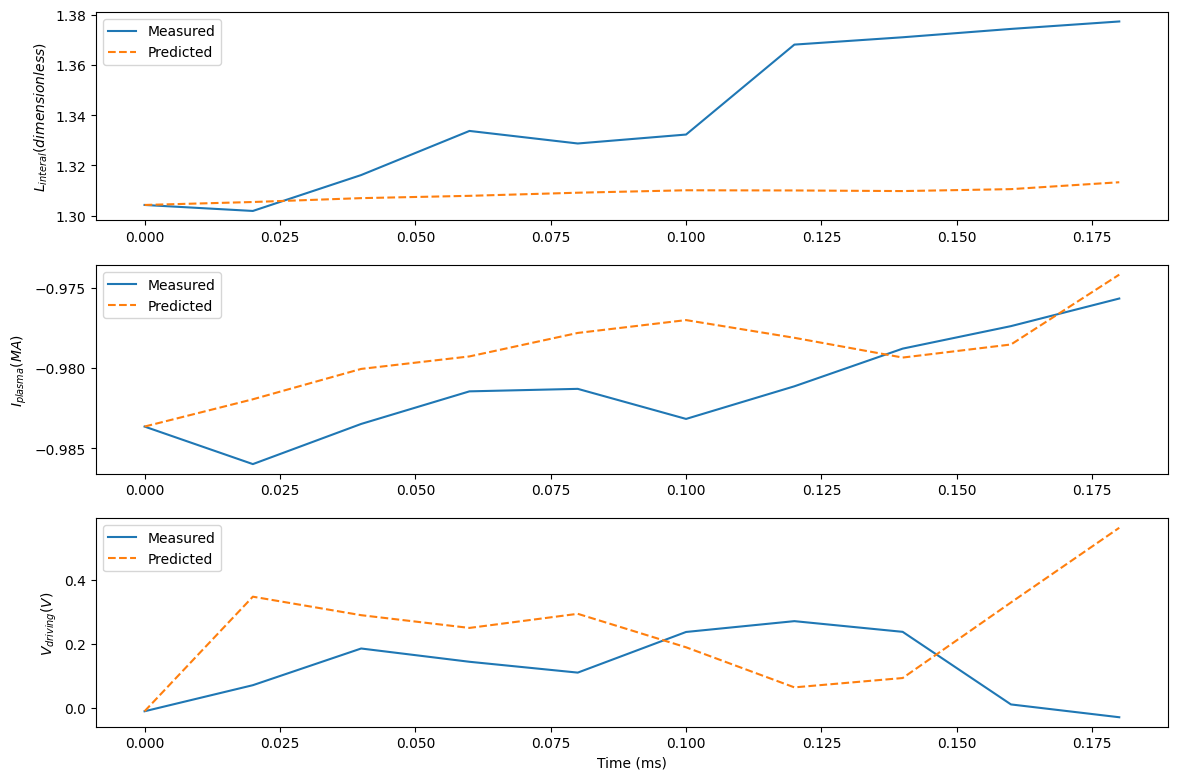

In [ ]:
init_state, controls, targets = test_eps[0]
preds = best_model(init_state, controls)

targets_np = np.stack(
    [targets["li"], targets["ip_MA"], targets["vc_minus_vb"]],
    axis=-1
)
preds_np = np.stack(
    [preds["li"], preds["ip_MA"], preds["vc_minus_vb"]],
    axis=-1
)

t = np.array(controls["time"])
t = t - t[0]   # start at 0

labels = ["$L_{interal} (dimensionless)$", "$I_{plasma} (MA)$", "$V_{driving} (V)$"]

plt.figure(figsize=(12, 8))

for i in range(3):
    plt.subplot(3, 1, i + 1)
    plt.plot(t, targets_np[:, i], label="Measured")
    plt.plot(t, preds_np[:, i], "--", label="Predicted")
    plt.ylabel(labels[i])
    plt.legend()

plt.xlabel("Time (ms)")
plt.rcParams.update({'font.size': 14})
plt.tight_layout()
plt.show()

In [ ]:
rmse = np.sqrt(np.mean((preds_np - targets_np)**2))
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")

Root Mean Squared Error (RMSE): 0.148861


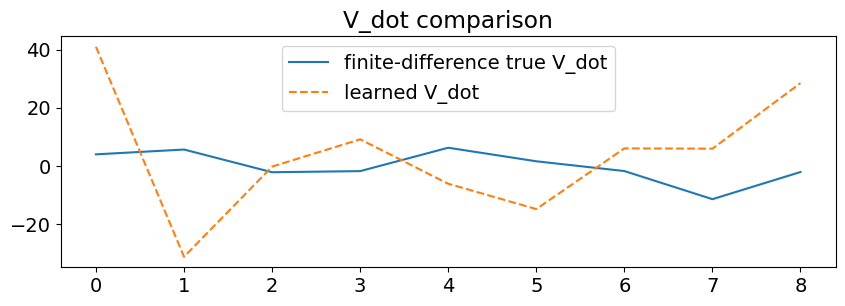

In [ ]:
init_state, controls, targets = test_eps[0]
preds = best_model(init_state, controls)

time = controls["time"]
true_vdot = (targets["vc_minus_vb"][1:] - targets["vc_minus_vb"][:-1]) / (time[1:] - time[:-1])

learned_vdot = []
state = init_state

for i in range(len(time) - 1):
    u = {"Vind": controls["Vind"][i]}
    dstate = best_model.dynamics(state, u)
    learned_vdot.append(dstate["vc_minus_vb"])
    state = jax.tree_util.tree_map(
        lambda s, ds: s + (time[i+1] - time[i]) * ds,
        state,
        dstate
    )

learned_vdot = jnp.array(learned_vdot)

plt.figure(figsize=(10, 3))
plt.plot(true_vdot, label="finite-difference true V_dot")
plt.plot(learned_vdot, "--", label="learned V_dot")
plt.legend()
plt.title("V_dot comparison")
plt.show()

In [ ]:
def simulate_li_ip_with_true_V(init_state, controls, targets, romero_norm=3.6559,li_scale=11.5,ip_scale=10.0):
    li0 = init_state["li"]
    ip0 = init_state["ip_MA"]

    time = controls["time"]
    Vind = controls["Vind"]
    V_true = targets["vc_minus_vb"]

    def step_fn(state, i):
        li, ip = state
        dt = time[i + 1] - time[i]

        V = V_true[i]
        Vb_minus_Vr = Vind[i]
        Vr_minus_Vb = -Vb_minus_Vr

        li_dot = li_scale * (2 * Vr_minus_Vb - 2 * V) / (romero_norm * ip)
        ip_dot = ip_scale * (2 * Vb_minus_Vr + V) / (romero_norm * li)

        next_state = (
            li + dt * li_dot,
            ip + dt * ip_dot,
        )

        return next_state, next_state

    _, traj = jax.lax.scan(
        step_fn,
        (li0, ip0),
        jnp.arange(len(time) - 1)
    )

    li_traj = jnp.concatenate([li0[None], traj[0]])
    ip_traj = jnp.concatenate([ip0[None], traj[1]])

    return li_traj, ip_traj

In [ ]:
li_errors = []
ip_errors = []

for init_state, controls, targets in test_eps:
    preds = best_model(init_state, controls)

    li_err = 100 * jnp.abs(preds["li"][-1] - targets["li"][-1]) / jnp.abs(targets["li"][-1])
    ip_err = 100 * jnp.abs(preds["ip_MA"][-1] - targets["ip_MA"][-1]) / jnp.abs(targets["ip_MA"][-1])

    li_errors.append(float(li_err))
    ip_errors.append(float(ip_err))

print("li mean ± std:", np.mean(li_errors), np.std(li_errors))
print("ip mean ± std:", np.mean(ip_errors), np.std(ip_errors))

li mean ± std: 4.2584123906066145 3.753959501641493
ip mean ± std: 2.526661987530022 1.572333247818624


In [ ]:
print("alpha_ip:", float(best_model.dynamics.alpha_ip))
print("alpha_li:", float(best_model.dynamics.alpha_li))

alpha_ip: 1.9111287593841553
alpha_li: 0.4798031747341156


In [ ]:
def interp_regular_control(time_old, Vind_old, dt_regular=0.01):
    t0 = time_old[0]
    t1 = time_old[-1]

    time_new = jnp.arange(t0, t1 + 1e-9, dt_regular)

    # linear interpolation onto regular grid
    Vind_new = jnp.interp(time_new, time_old, Vind_old)

    Vind_slope_new = backward_slopes(Vind_new, time_new)

    controls_new = {
        "time": time_new,
        "Vind": Vind_new,
        "Vind_slope": Vind_slope_new,
    }

    return controls_new


def simulate_regular_with_derivatives(model, init_state, controls, dt_regular=0.01):
    controls_reg = interp_regular_control(
        controls["time"],
        controls["Vind"],
        dt_regular=dt_regular,
    )

    preds = model(init_state, controls_reg)

    def deriv_at_state(state, i):
        control_i = {
            "Vind": controls_reg["Vind"][i]
        }
        return model.dynamics(state, control_i)

    derivs = jax.vmap(deriv_at_state)(
        preds,
        jnp.arange(preds["li"].shape[0])
    )

    return controls_reg["time"], preds, derivs

In [ ]:
def full_shot_rollout(best_model, df, dt_regular=0.01):
    time_raw = jnp.array(df["time"].values)
    Vind_raw = jnp.array(df["Vind"].values)

    init_state = {
        "li": jnp.array(df["li"].values[0]),
        "ip_MA": jnp.array(df["ip_MA"].values[0]),
        "vc_minus_vb": jnp.array(df["vc_minus_vb"].values[0]),
    }

    controls = {
        "time": time_raw,
        "Vind": Vind_raw,
        "Vind_slope": backward_slopes(Vind_raw, time_raw),
    }

    time_reg, preds_reg, derivs_reg = simulate_regular_with_derivatives(
        best_model,
        init_state,
        controls,
        dt_regular=dt_regular,
    )

    return time_reg, preds_reg, derivs_reg


def compare_full_shot(best_model, df, dt_regular=0.01):
    time_reg, preds_reg, derivs_reg = full_shot_rollout(
        best_model,
        df,
        dt_regular=dt_regular,
    )

    time_raw = jnp.array(df["time"].values)

    targets_reg = {
        "li": jnp.interp(time_reg, time_raw, jnp.array(df["li"].values)),
        "ip_MA": jnp.interp(time_reg, time_raw, jnp.array(df["ip_MA"].values)),
        "vc_minus_vb": jnp.interp(time_reg, time_raw, jnp.array(df["vc_minus_vb"].values)),
    }

    t = np.array(time_reg - time_reg[0])

    labels = {
        "li": "li",
        "ip_MA": "ip_MA",
        "vc_minus_vb": "V",
    }

    plt.figure(figsize=(12, 8))

    for i, key in enumerate(["li", "ip_MA", "vc_minus_vb"]):
        plt.subplot(3, 1, i + 1)
        plt.plot(t, np.array(targets_reg[key]), label=f"Measured {labels[key]}")
        plt.plot(t, np.array(preds_reg[key]), "--", label=f"Predicted {labels[key]}")
        plt.ylabel(labels[key])
        plt.legend()

    plt.xlabel("Time since shot start")
    plt.tight_layout()
    plt.show()

    print("Full-shot metrics:")

    for key in ["li", "ip_MA", "vc_minus_vb"]:
        y_true = targets_reg[key]
        y_pred = preds_reg[key]

        rmse = jnp.sqrt(jnp.mean((y_pred - y_true) ** 2))
        mae = jnp.mean(jnp.abs(y_pred - y_true))
        end_pct = 100 * jnp.abs(y_pred[-1] - y_true[-1]) / (jnp.abs(y_true[-1]) + 1e-8)

        print(
            f"{key}: "
            f"RMSE={float(rmse):.6f}, "
            f"MAE={float(mae):.6f}, "
            f"end % error={float(end_pct):.3f}%"
        )

    return time_reg, preds_reg, targets_reg, derivs_reg

In [ ]:
class RomeroAnalytic(eqx.Module):
    romero_norm: float
    kappa: float
    tau: float
    alpha_li: float
    alpha_ip: float

    def __init__(self):
        self.romero_norm = 3.6559
        self.kappa = 0.98
        self.tau = 1.25
        self.alpha_li = 1.0
        self.alpha_ip = 1.0

    def __call__(self, state, control):
        li = state["li"]
        ip = state["ip_MA"]
        V = state["vc_minus_vb"]
        Vind = control["Vind"]

        Vb_minus_Vr = Vind
        Vr_minus_Vb = -Vb_minus_Vr

        li_dot = self.alpha_li * (2 * Vr_minus_Vb - 2 * V) / (self.romero_norm * ip)
        ip_dot = self.alpha_ip * (2 * Vb_minus_Vr + V) / (self.romero_norm * li)

        V_dot = -(V / self.tau) + (self.kappa / self.tau) * Vr_minus_Vb

        return {
            "li": li_dot,
            "ip_MA": ip_dot,
            "vc_minus_vb": V_dot,
        }

In [ ]:
romero_model = SimFullObs(RomeroAnalytic())

In [ ]:
def compare_full_shot_two_models(model_a, model_b, df, label_a="RomeroNNV", label_b="Analytic Romero", dt_regular=0.01):
    time_a, preds_a, derivs_a = full_shot_rollout(model_a, df, dt_regular)
    time_b, preds_b, derivs_b = full_shot_rollout(model_b, df, dt_regular)

    time_raw = jnp.array(df["time"].values)

    targets = {
        "li": jnp.interp(time_a, time_raw, jnp.array(df["li"].values)),
        "ip_MA": jnp.interp(time_a, time_raw, jnp.array(df["ip_MA"].values)),
        "vc_minus_vb": jnp.interp(time_a, time_raw, jnp.array(df["vc_minus_vb"].values)),
    }

    t = np.array(time_a - time_a[0])

    plt.figure(figsize=(12, 8))

    for i, key in enumerate(["li", "ip_MA", "vc_minus_vb"]):
        plt.subplot(3, 1, i + 1)
        plt.plot(t, np.array(targets[key]), label="Measured")
        plt.plot(t, np.array(preds_a[key]), "--", label=label_a)
        plt.plot(t, np.array(preds_b[key]), ":", label=label_b)
        plt.ylabel(key)
        plt.legend()

    plt.xlabel("Time since shot start")
    plt.tight_layout()
    plt.show()

    for model_label, preds in [(label_a, preds_a), (label_b, preds_b)]:
        print(model_label)

        for key in ["li", "ip_MA", "vc_minus_vb"]:
            y_true = targets[key]
            y_pred = preds[key]

            rmse = jnp.sqrt(jnp.mean((y_pred - y_true) ** 2))
            mae = jnp.mean(jnp.abs(y_pred - y_true))
            end_pct = 100 * jnp.abs(y_pred[-1] - y_true[-1]) / (jnp.abs(y_true[-1]) + 1e-8)

            print(
                f"  {key}: "
                f"RMSE={float(rmse):.6f}, "
                f"MAE={float(mae):.6f}, "
                f"end % error={float(end_pct):.3f}%"
            )

In [ ]:
romero_model = SimFullObs(
    RomeroAnalytic()
)

romero_model = eqx.tree_at(
    lambda m: (m.dynamics.alpha_li, m.dynamics.alpha_ip),
    romero_model,
    (float(best_model.dynamics.alpha_li), float(best_model.dynamics.alpha_ip)),
)

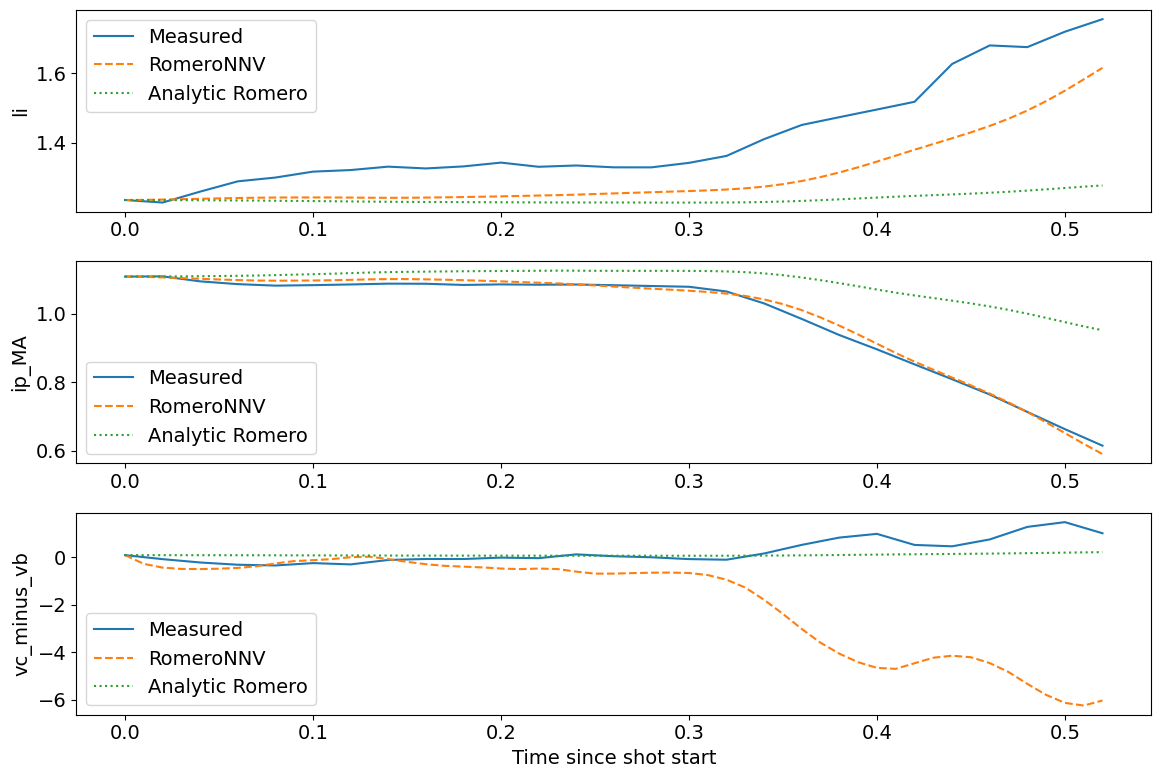

RomeroNNV
  li: RMSE=0.119025, MAE=0.104755, end % error=7.953%
  ip_MA: RMSE=0.012474, MAE=0.010348, end % error=4.003%
  vc_minus_vb: RMSE=3.301340, MAE=2.144651, end % error=693.267%
Analytic Romero
  li: RMSE=0.218745, MAE=0.172300, end % error=27.181%
  ip_MA: RMSE=0.140609, MAE=0.099553, end % error=55.007%
  vc_minus_vb: RMSE=0.483219, MAE=0.357833, end % error=78.275%


In [ ]:
compare_full_shot_two_models(
    best_model,
    romero_model,
    df_list[0],
)

In [ ]:
def endpoint_percent_errors(model, eps, name="set"):
    li_errors = []
    ip_errors = []

    for init_state, controls, targets in eps:
        preds = model(init_state, controls)

        li_err = 100 * jnp.abs(preds["li"][-1] - targets["li"][-1]) / (jnp.abs(targets["li"][-1]) + 1e-8)
        ip_err = 100 * jnp.abs(preds["ip_MA"][-1] - targets["ip_MA"][-1]) / (jnp.abs(targets["ip_MA"][-1]) + 1e-8)

        li_errors.append(float(li_err))
        ip_errors.append(float(ip_err))

    print(f"{name} li mean ± std:", np.mean(li_errors), np.std(li_errors))
    print(f"{name} ip mean ± std:", np.mean(ip_errors), np.std(ip_errors))

In [ ]:
endpoint_percent_errors(best_model, train_eps, "Train")
endpoint_percent_errors(best_model, val_eps, "Validation")
endpoint_percent_errors(best_model, test_eps, "Test")

Train li mean ± std: 3.9561016639701982 3.798008931280473
Train ip mean ± std: 2.599160501273937 1.5086567193247507
Validation li mean ± std: 3.8817609380612508 3.5676581540230576
Validation ip mean ± std: 2.5084905054663187 1.44359205407164
Test li mean ± std: 4.2584123906066145 3.753959501641493
Test ip mean ± std: 2.526661987530022 1.572333247818624


In [ ]:
def plot_V_for_training_shots(train_dfs, max_shots=None):
    dfs_to_plot = train_dfs if max_shots is None else train_dfs[:max_shots]

    plt.figure(figsize=(12, 6))

    for df in dfs_to_plot:
        t = np.array(df["time"].values)
        t = t - t[0]

        V = np.array(df["vc_minus_vb"].values)

        plt.plot(t, V, alpha=0.25)

    plt.xlabel("Time since shot start")
    plt.ylabel("V = vc_minus_vb")
    plt.title(f"V time series for training shots, n={len(dfs_to_plot)}")
    plt.tight_layout()
    plt.show()

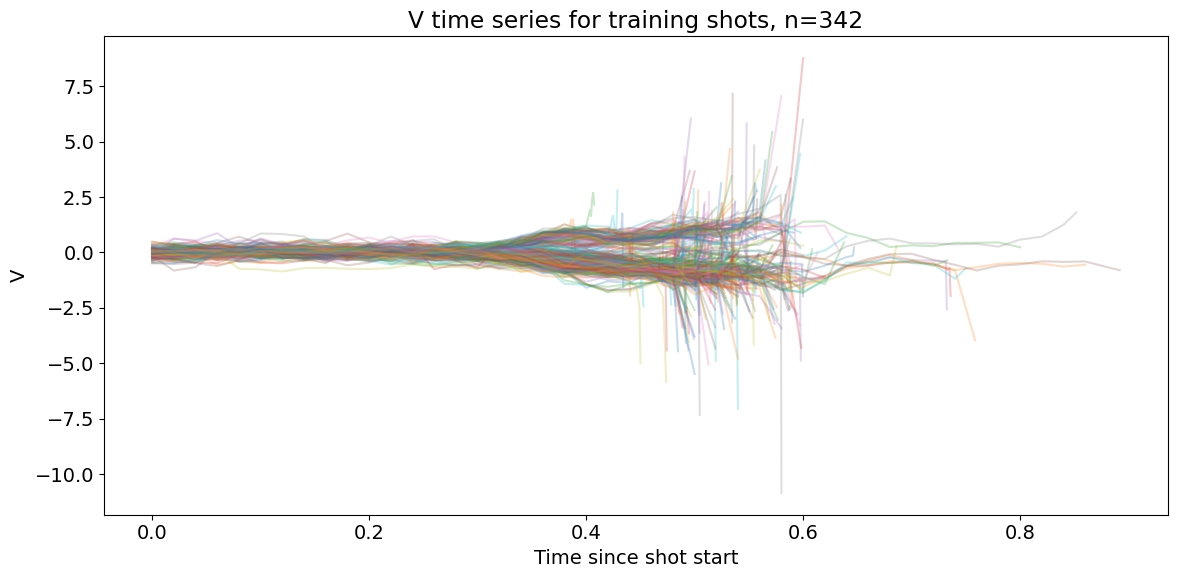

In [ ]:
plot_V_for_training_shots(train_dfs)

In [ ]:
def plot_V_normalized_time(train_dfs, max_shots=None):
    dfs_to_plot = train_dfs if max_shots is None else train_dfs[:max_shots]

    plt.figure(figsize=(12, 6))

    for df in dfs_to_plot:

        V = np.array(df["vc_minus_vb"].values)

        # normalized time axis
        t_norm = np.linspace(0, 1, len(V))

        plt.plot(t_norm, V, alpha=0.25)

    plt.xlabel("Normalized shot time")
    plt.ylabel("V = vc_minus_vb")
    plt.title(f"Normalized V trajectories, n={len(dfs_to_plot)}")
    plt.tight_layout()
    plt.show()

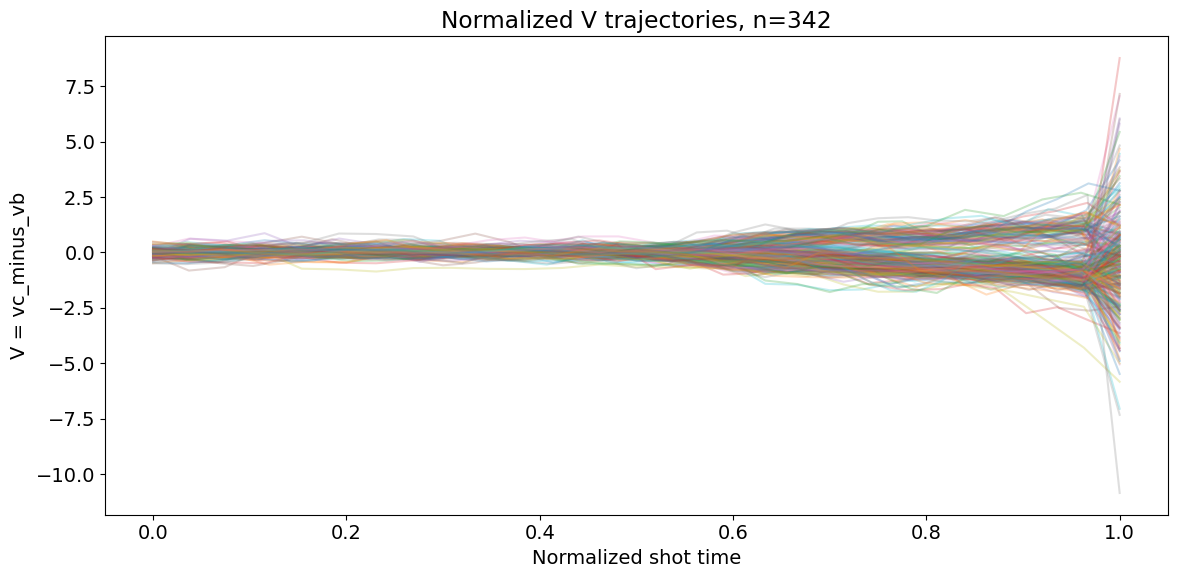

In [ ]:
plot_V_normalized_time(train_dfs)

# Interpolate measured V and analytic V onto a common normalized grid

In [ ]:
def rollout_model_full_shot(model, df):
    time_raw = jnp.array(df["time"].values)
    Vind_raw = jnp.array(df["Vind"].values)

    init_state = {
        "li": jnp.array(df["li"].values[0]),
        "ip_MA": jnp.array(df["ip_MA"].values[0]),
        "vc_minus_vb": jnp.array(df["vc_minus_vb"].values[0]),
    }

    controls = {
        "time": time_raw,
        "Vind": Vind_raw,
        "Vind_slope": backward_slopes(Vind_raw, time_raw),
    }

    preds = model(init_state, controls)
    return time_raw, preds

In [ ]:
def collect_V_comparison_over_shots(dfs, analytic_model, n_grid=200):
    tau_grid = jnp.linspace(0.0, 1.0, n_grid)

    measured_V_all = []
    analytic_V_all = []

    for df in dfs:
        time_raw = jnp.array(df["time"].values)
        t_norm_raw = (time_raw - time_raw[0]) / (time_raw[-1] - time_raw[0])

        V_measured = jnp.array(df["vc_minus_vb"].values)

        _, preds_analytic = rollout_model_full_shot(analytic_model, df)
        V_analytic = preds_analytic["vc_minus_vb"]

        V_measured_grid = jnp.interp(tau_grid, t_norm_raw, V_measured)
        V_analytic_grid = jnp.interp(tau_grid, t_norm_raw, V_analytic)

        measured_V_all.append(V_measured_grid)
        analytic_V_all.append(V_analytic_grid)

    measured_V_all = jnp.stack(measured_V_all)
    analytic_V_all = jnp.stack(analytic_V_all)

    return tau_grid, measured_V_all, analytic_V_all

In [ ]:
def plot_V_mean_std_comparison(dfs, analytic_model, n_grid=200, title="Training shots"):
    tau_grid, measured_V, analytic_V = collect_V_comparison_over_shots(
        dfs,
        analytic_model,
        n_grid=n_grid,
    )

    measured_mean = jnp.mean(measured_V, axis=0)
    measured_std  = jnp.std(measured_V, axis=0)

    analytic_mean = jnp.mean(analytic_V, axis=0)
    analytic_std  = jnp.std(analytic_V, axis=0)

    tau = np.array(tau_grid)

    plt.figure(figsize=(12, 6))

    plt.plot(tau, np.array(measured_mean), label="Measured V mean")
    plt.fill_between(
        tau,
        np.array(measured_mean - measured_std),
        np.array(measured_mean + measured_std),
        alpha=0.2,
        label="Measured V ±1 std",
    )

    plt.plot(tau, np.array(analytic_mean), "--", label="Analytic Romero V mean")
    plt.fill_between(
        tau,
        np.array(analytic_mean - analytic_std),
        np.array(analytic_mean + analytic_std),
        alpha=0.2,
        label="Analytic Romero V ±1 std",
    )

    plt.xlabel("Normalized shot time")
    plt.ylabel("V = vc_minus_vb")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    rmse = jnp.sqrt(jnp.mean((analytic_V - measured_V) ** 2))
    mae = jnp.mean(jnp.abs(analytic_V - measured_V))

    print(f"{title} analytic V RMSE: {float(rmse):.6f}")
    print(f"{title} analytic V MAE:  {float(mae):.6f}")

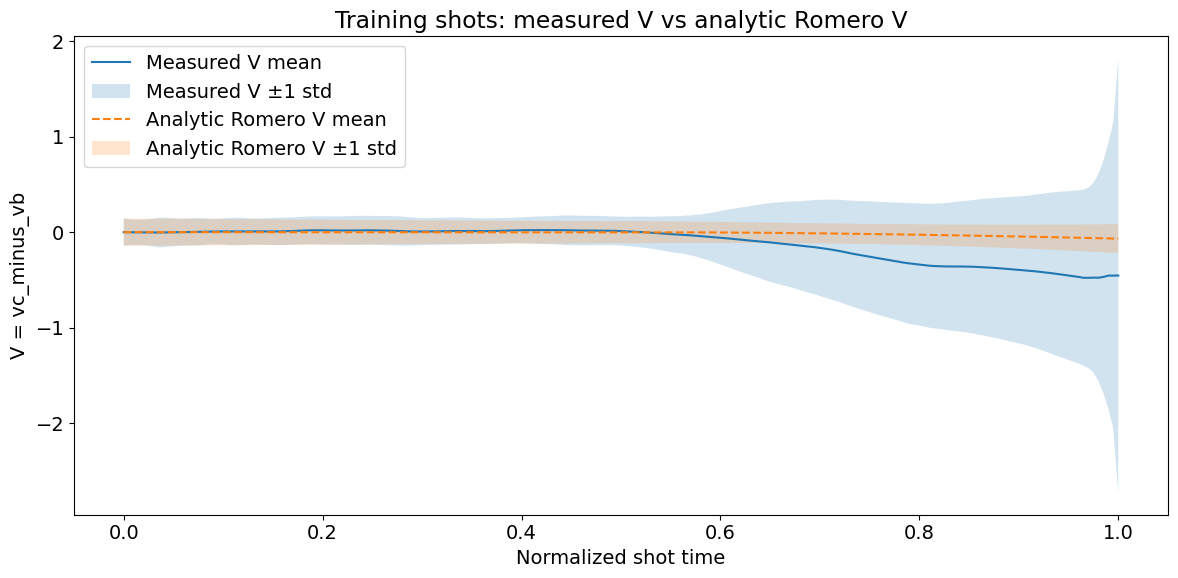

Training shots: measured V vs analytic Romero V analytic V RMSE: 0.499742
Training shots: measured V vs analytic Romero V analytic V MAE:  0.329599


In [ ]:
plot_V_mean_std_comparison(
    train_dfs,
    romero_model,
    n_grid=200,
    title="Training shots: measured V vs analytic Romero V",
)

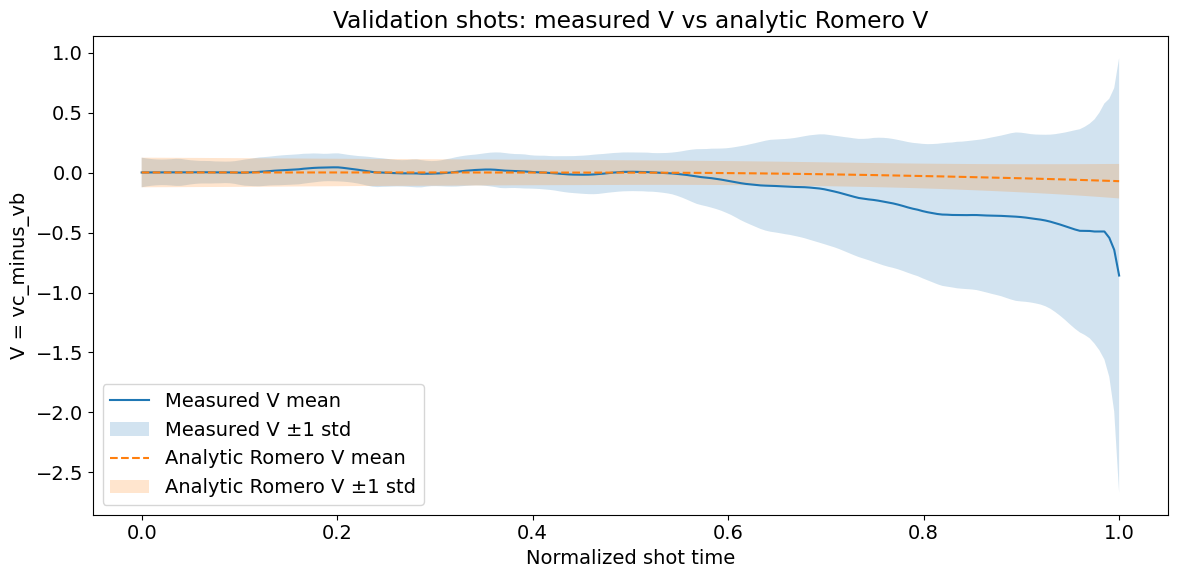

Validation shots: measured V vs analytic Romero V analytic V RMSE: 0.448186
Validation shots: measured V vs analytic Romero V analytic V MAE:  0.292170


In [ ]:
plot_V_mean_std_comparison(
    val_dfs,
    romero_model,
    n_grid=200,
    title="Validation shots: measured V vs analytic Romero V",
)

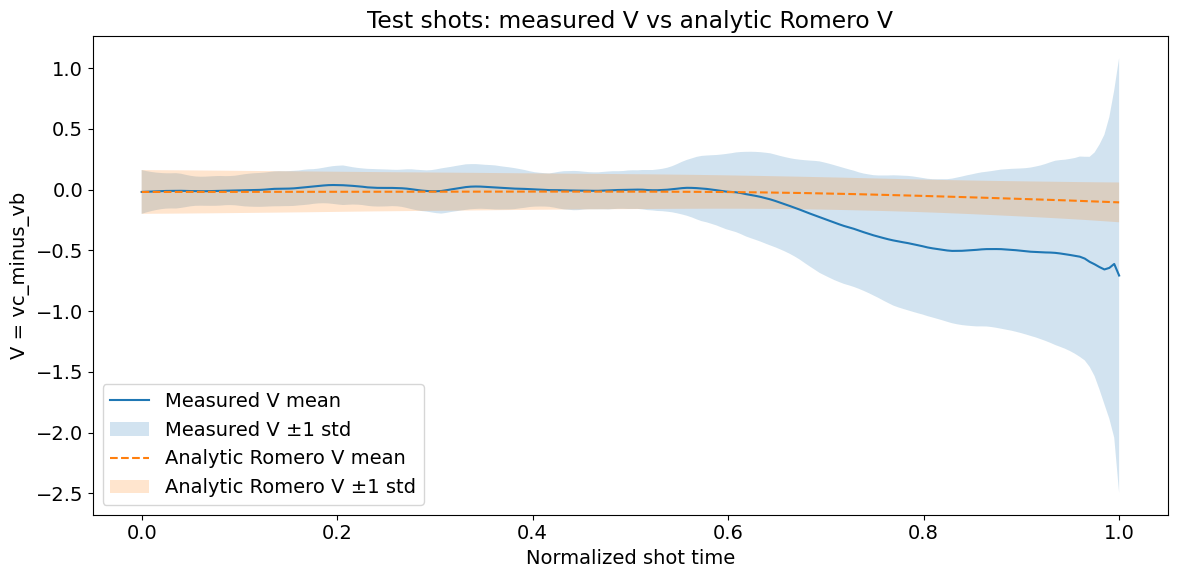

Test shots: measured V vs analytic Romero V analytic V RMSE: 0.486099
Test shots: measured V vs analytic Romero V analytic V MAE:  0.331780


In [ ]:
plot_V_mean_std_comparison(
    test_dfs,
    romero_model,
    n_grid=200,
    title="Test shots: measured V vs analytic Romero V",
)

In [ ]:
def collect_model_vs_measured_over_shots(dfs, model, signal_key, n_grid=200):
    tau_grid = jnp.linspace(0.0, 1.0, n_grid)

    measured_all = []
    predicted_all = []

    for df in dfs:
        time_raw = jnp.array(df["time"].values)
        t_norm_raw = (time_raw - time_raw[0]) / (time_raw[-1] - time_raw[0])

        # measured signal
        measured = jnp.array(df[signal_key].values)

        # model rollout over full shot
        time_model, preds_model, _ = full_shot_rollout(
            model,
            df,
            dt_regular=0.01,
        )

        t_norm_model = (time_model - time_model[0]) / (time_model[-1] - time_model[0])

        measured_grid = jnp.interp(tau_grid, t_norm_raw, measured)
        predicted_grid = jnp.interp(tau_grid, t_norm_model, preds_model[signal_key])

        measured_all.append(measured_grid)
        predicted_all.append(predicted_grid)

    return tau_grid, jnp.stack(measured_all), jnp.stack(predicted_all)

In [ ]:
def plot_ode_results_li_ip(dfs, model, title="Training shots", n_grid=200):
    tau_grid, li_meas, li_pred = collect_model_vs_measured_over_shots(
        dfs, model, "li", n_grid=n_grid
    )
    _, ip_meas, ip_pred = collect_model_vs_measured_over_shots(
        dfs, model, "ip_MA", n_grid=n_grid
    )

    tau = np.array(tau_grid)

    plt.figure(figsize=(12, 8))

    for i, (name, measured, predicted) in enumerate([
        ("li", li_meas, li_pred),
        ("ip_MA", ip_meas, ip_pred),
    ]):
        meas_mean = jnp.mean(measured, axis=0)
        meas_std = jnp.std(measured, axis=0)

        pred_mean = jnp.mean(predicted, axis=0)
        pred_std = jnp.std(predicted, axis=0)

        plt.subplot(2, 1, i + 1)

        plt.plot(tau, np.array(meas_mean), label=f"Measured {name} mean")
        plt.fill_between(
            tau,
            np.array(meas_mean - meas_std),
            np.array(meas_mean + meas_std),
            alpha=0.2,
            label=f"Measured {name} ±1 std",
        )

        plt.plot(tau, np.array(pred_mean), "--", label=f"ODE predicted {name} mean")
        plt.fill_between(
            tau,
            np.array(pred_mean - pred_std),
            np.array(pred_mean + pred_std),
            alpha=0.2,
            label=f"ODE predicted {name} ±1 std",
        )

        plt.ylabel(name)
        plt.legend()

    plt.xlabel("Normalized shot time")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

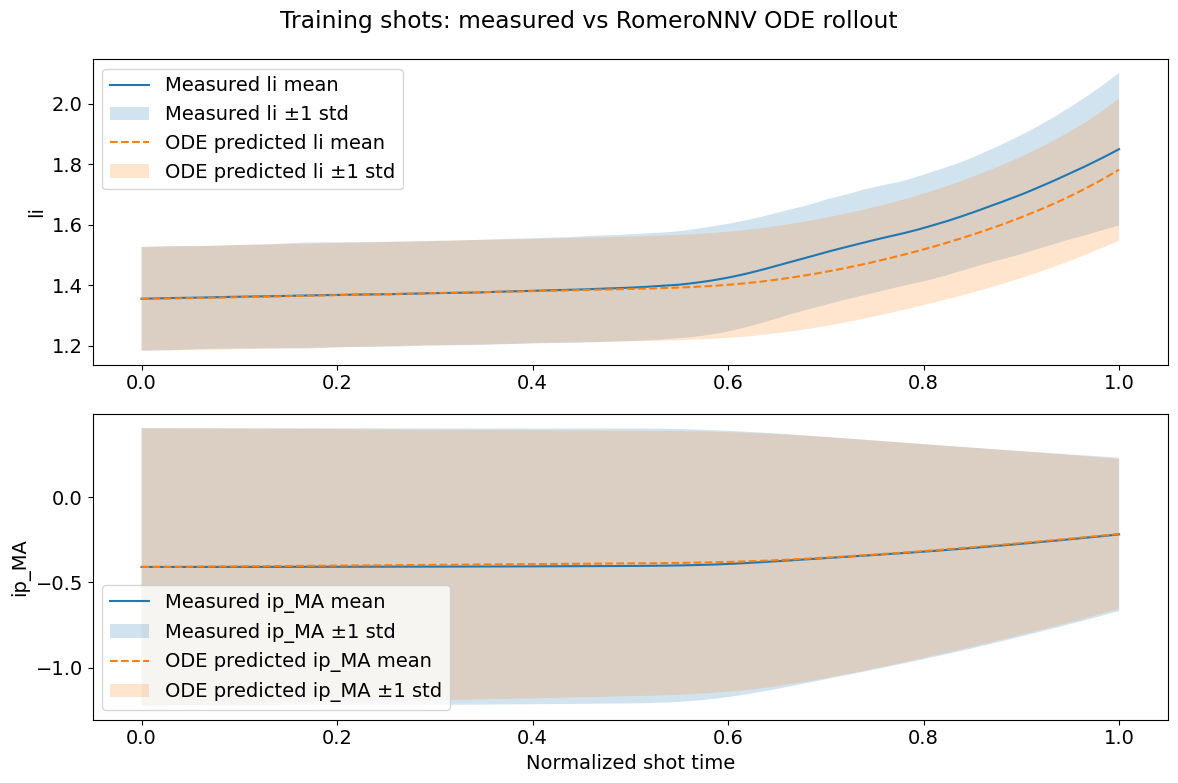

In [ ]:
plot_ode_results_li_ip(
    train_dfs,
    best_model,
    title="Training shots: measured vs RomeroNNV ODE rollout",
)

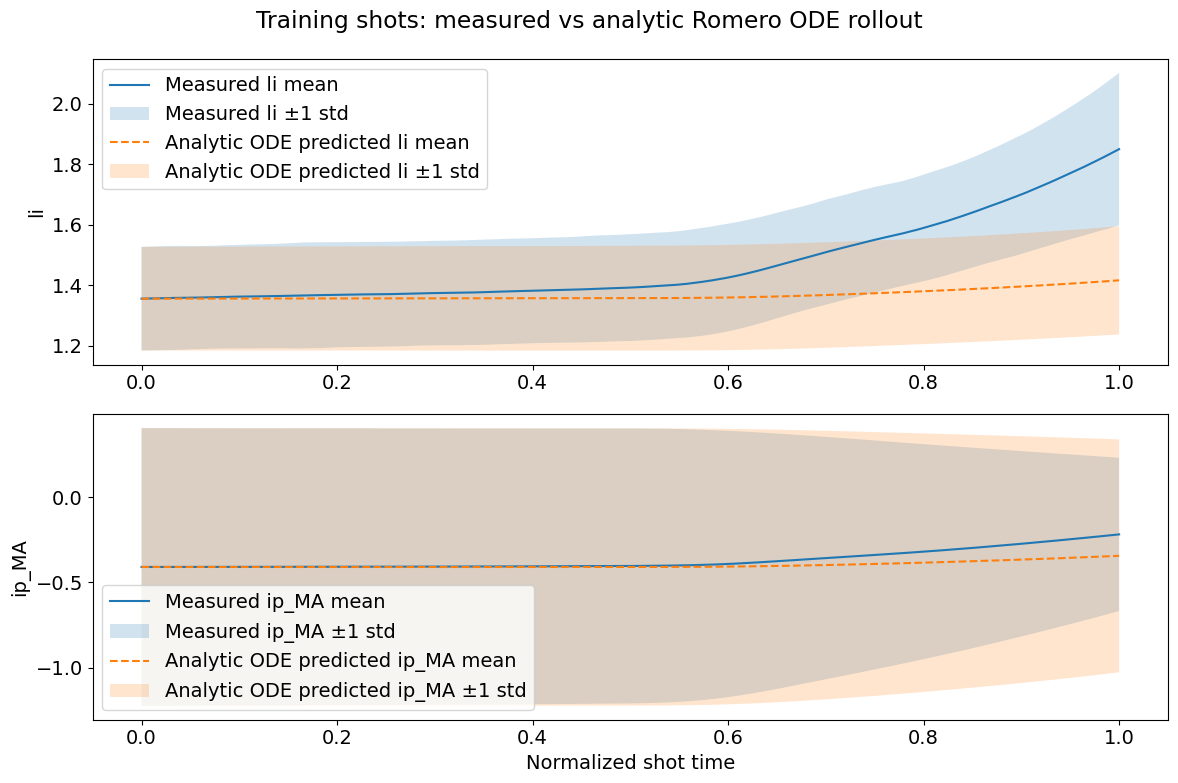

In [ ]:
plot_ode_results_li_ip(
    train_dfs,
    romero_model,
    title="Training shots: measured vs analytic Romero ODE rollout",
)

In [ ]:
def collect_two_model_comparison(dfs, model_a, model_b, signal_key, n_grid=200):
    tau_grid = jnp.linspace(0.0, 1.0, n_grid)

    measured_all = []
    pred_a_all = []
    pred_b_all = []

    for df in dfs:
        time_raw = jnp.array(df["time"].values)
        t_norm_raw = (time_raw - time_raw[0]) / (time_raw[-1] - time_raw[0])

        measured = jnp.array(df[signal_key].values)

        time_a, preds_a, _ = full_shot_rollout(model_a, df, dt_regular=0.01)
        time_b, preds_b, _ = full_shot_rollout(model_b, df, dt_regular=0.01)

        t_norm_a = (time_a - time_a[0]) / (time_a[-1] - time_a[0])
        t_norm_b = (time_b - time_b[0]) / (time_b[-1] - time_b[0])

        measured_all.append(jnp.interp(tau_grid, t_norm_raw, measured))
        pred_a_all.append(jnp.interp(tau_grid, t_norm_a, preds_a[signal_key]))
        pred_b_all.append(jnp.interp(tau_grid, t_norm_b, preds_b[signal_key]))

    return (
        tau_grid,
        jnp.stack(measured_all),
        jnp.stack(pred_a_all),
        jnp.stack(pred_b_all),
    )


def plot_li_ip_three_way(
    dfs,
    romero_nnv_model,
    analytic_romero_model,
    title="Training shots",
    n_grid=200,
):
    for signal_key, ylabel in [
        ("li", "li"),
        ("ip_MA", "ip_MA"),
    ]:
        tau, measured, nnv, analytic = collect_two_model_comparison(
            dfs,
            romero_nnv_model,
            analytic_romero_model,
            signal_key,
            n_grid=n_grid,
        )

        tau_np = np.array(tau)

        measured_mean = jnp.mean(measured, axis=0)
        nnv_mean = jnp.mean(nnv, axis=0)
        analytic_mean = jnp.mean(analytic, axis=0)

        measured_std = jnp.std(measured, axis=0)
        nnv_std = jnp.std(nnv, axis=0)
        analytic_std = jnp.std(analytic, axis=0)

        plt.figure(figsize=(12, 5))

        plt.plot(tau_np, np.array(measured_mean), label=f"Measured {ylabel} mean")
        plt.fill_between(
            tau_np,
            np.array(measured_mean - measured_std),
            np.array(measured_mean + measured_std),
            alpha=0.15,
        )

        plt.plot(tau_np, np.array(nnv_mean), "--", label=f"RomeroNNV {ylabel} mean")
        plt.fill_between(
            tau_np,
            np.array(nnv_mean - nnv_std),
            np.array(nnv_mean + nnv_std),
            alpha=0.15,
        )

        plt.plot(tau_np, np.array(analytic_mean), ":", label=f"Analytic Romero {ylabel} mean")
        plt.fill_between(
            tau_np,
            np.array(analytic_mean - analytic_std),
            np.array(analytic_mean + analytic_std),
            alpha=0.15,
        )

        plt.xlabel("Normalized shot time")
        plt.ylabel(ylabel)
        plt.title(f"{title}: {ylabel} measured vs RomeroNNV vs analytic Romero")
        plt.legend()
        plt.tight_layout()
        plt.show()

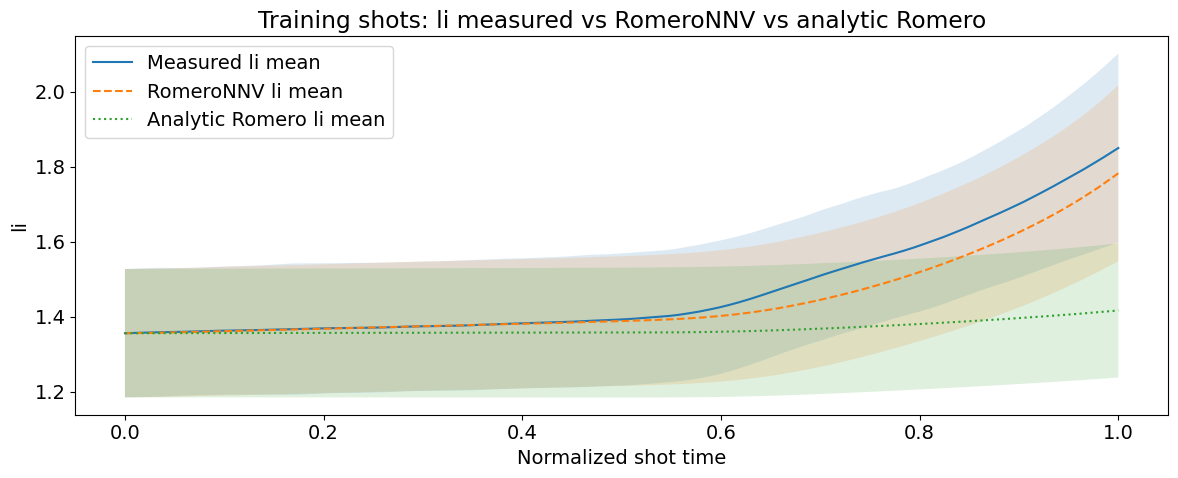

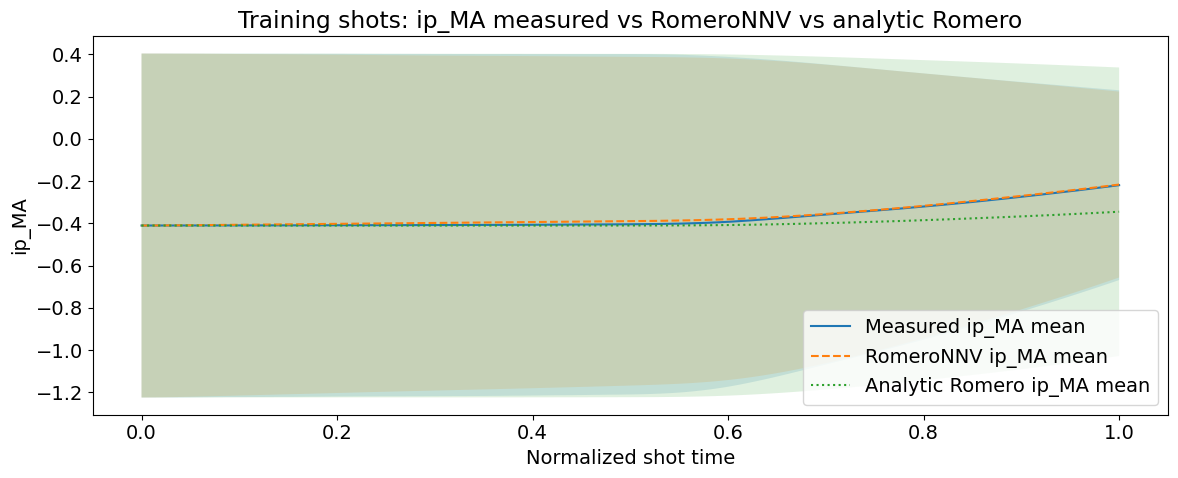

In [ ]:
plot_li_ip_three_way(
    train_dfs,
    best_model,
    romero_model,
    title="Training shots",
)

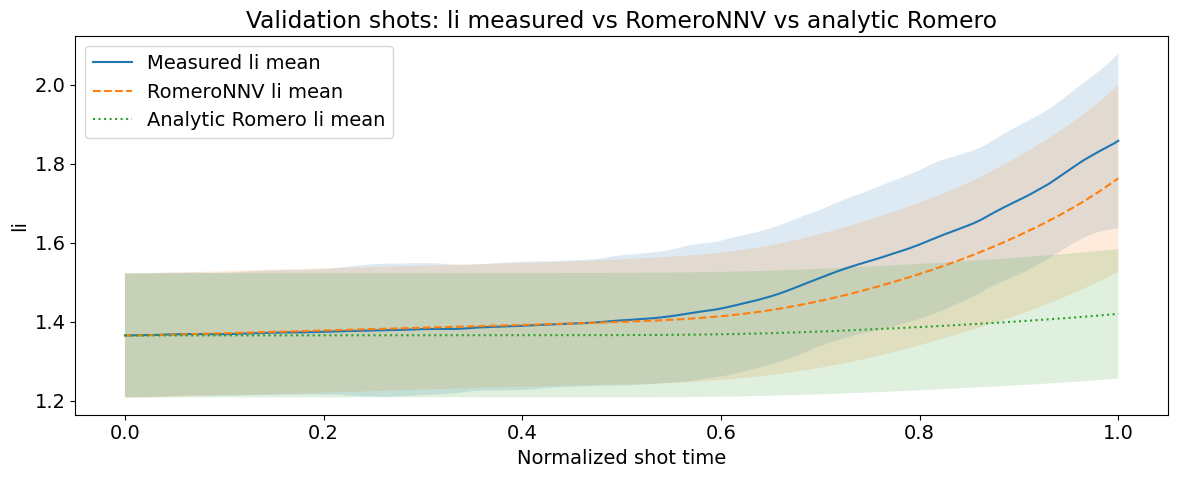

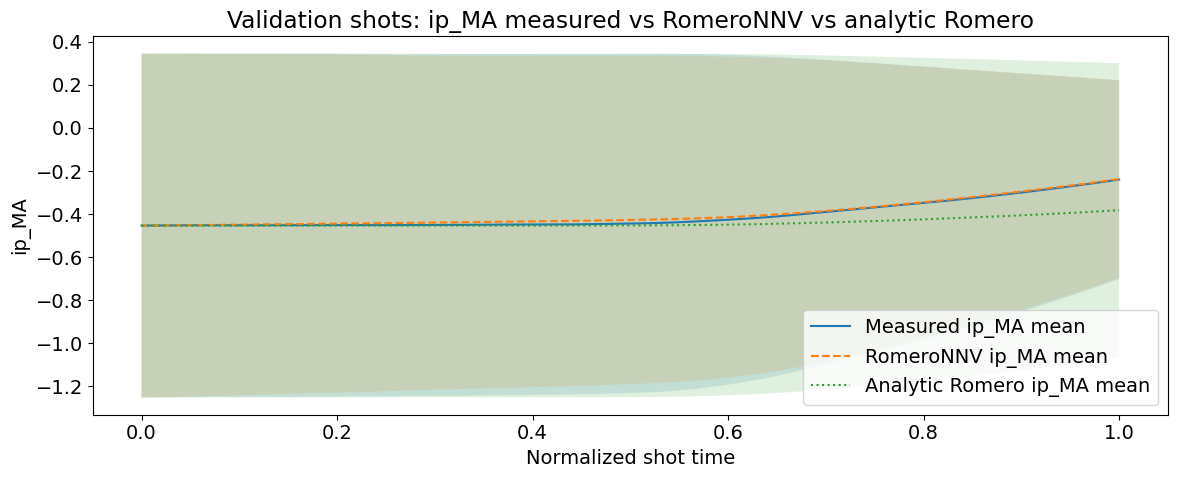

In [ ]:
plot_li_ip_three_way(val_dfs, best_model, romero_model, title="Validation shots")

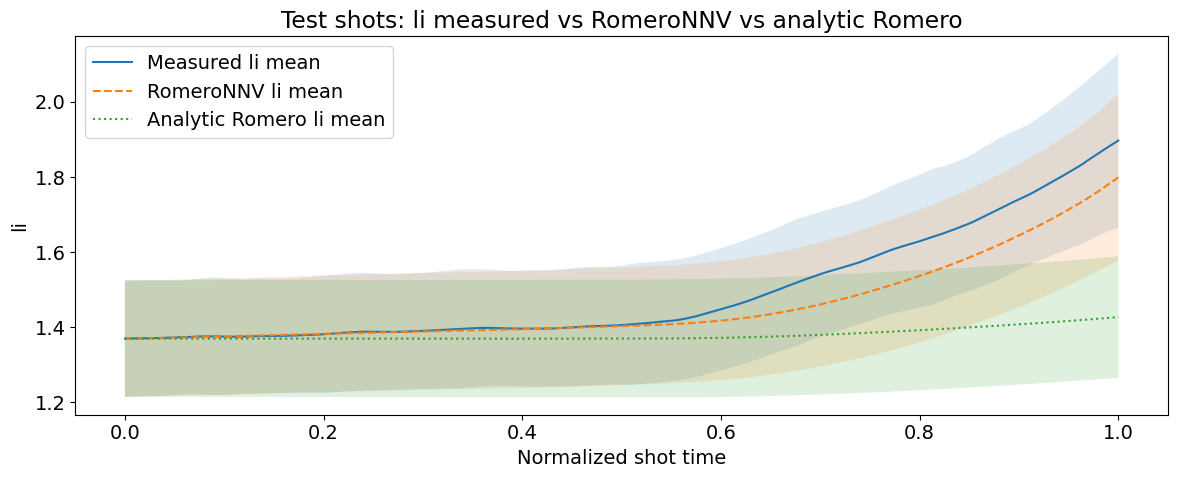

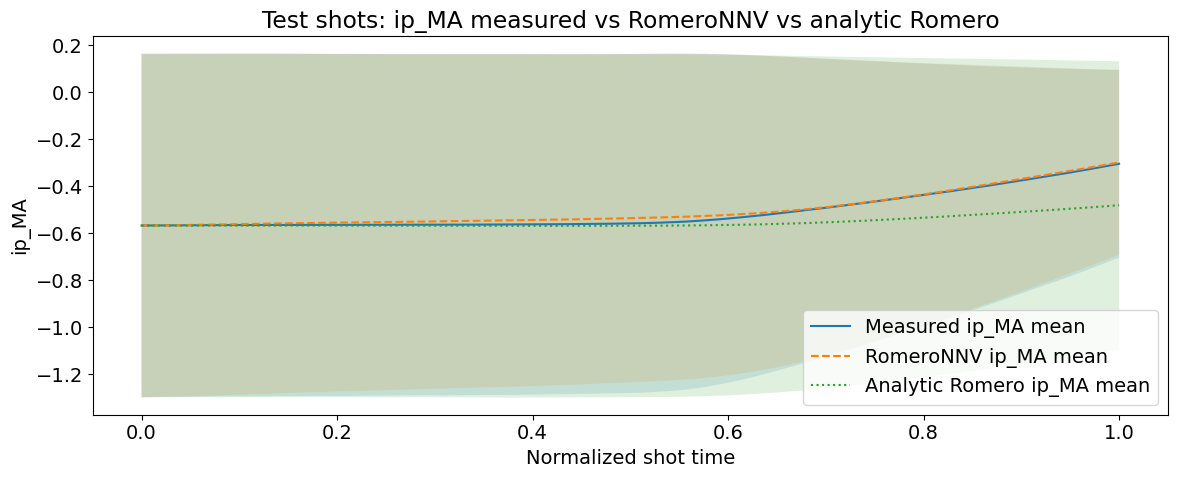

In [ ]:
plot_li_ip_three_way(test_dfs, best_model, romero_model, title="Test shots")